In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("all_data.csv")
data.head()

C:\Users\User\AppData\Local\Temp\ipykernel_3952\1625381725.py:1: DtypeWarning: Columns (0,51) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("all_data.csv")


,發生年度,發生月份,發生日期,發生時間,事故類別名稱,處理單位名稱警局層,發生地點,天候名稱,光線名稱,道路類別-第1當事者-名稱,...,車輛撞擊部位大類別名稱-最初,車輛撞擊部位子類別名稱-最初,車輛撞擊部位大類別名稱-其他,車輛撞擊部位子類別名稱-其他,肇因研判大類別名稱-個別,肇因研判子類別名稱-個別,肇事逃逸類別名稱-是否肇逃,經度,緯度,共享經濟或外送平台的名稱
0,2022,1.0,20220101.0,23000.0,A1,雲林縣警察局,雲林縣虎尾鎮雲145公路路燈290570號,晴,夜間(或隧道、地下道、涵洞)有照明,市區道路,...,機車,前車頭,NaN,NaN,駕駛人,未注意車前狀態,否,120.411444,23.686485,NaN
1,2022,1.0,20220101.0,23000.0,A1,雲林縣警察局,雲林縣虎尾鎮雲145公路路燈290570號,晴,夜間(或隧道、地下道、涵洞)有照明,市區道路,...,NaN,NaN,NaN,NaN,無(非車輛駕駛人因素),尚未發現肇事因素,否,120.411444,23.686485,NaN
2,2022,1.0,20220101.0,60742.0,A1,國道公路警察局,屏東縣九如鄉國道3號 393公里600.0公尺處南側向外側,晴,晨或暮光,國道,...,汽車,前車頭,NaN,NaN,駕駛人,未注意車前狀態,否,120.489248,22.733474,NaN
3,2022,1.0,20220101.0,60742.0,A1,國道公路警察局,屏東縣九如鄉國道3號 393公里600.0公尺處南側向外側,晴,晨或暮光,國道,...,汽車,後車尾,NaN,NaN,無(車輛駕駛人因素),尚未發現肇事因素,否,120.489248,22.733474,NaN
4,2022,1.0,20220101.0,60742.0,A1,國道公路警察局,屏東縣九如鄉國道3號 393公里600.0公尺處南側向外側,晴,晨或暮光,國道,...,NaN,NaN,NaN,NaN,無(非車輛駕駛人因素),尚未發現肇事因素,否,120.489248,22.733474,NaN


In [3]:
data['發生日期_str'] = data['發生日期'].fillna(0).astype(int).astype(str)
data['發生時間_str'] = data['發生時間'].fillna(0).astype(int).astype(str).str.zfill(4)

# Concatenate the cleaned date and formatted time strings
data['datetime_temp'] = data['發生日期_str'] + data['發生時間_str']

# Convert the combined string to datetime objects
data['datetime_full'] = pd.to_datetime(data['datetime_temp'], format='%Y%m%d%H%M%S', errors='coerce')

# Extract Hour, DayOfWeek, and Month
data['Hour'] = data['datetime_full'].dt.hour
data['DayOfWeek'] = data['datetime_full'].dt.dayofweek
data['Month'] = data['datetime_full'].dt.month

# Display the first few rows to verify the transformation
display(data[['發生日期', '發生時間', 'datetime_full', 'Hour', 'DayOfWeek', 'Month']].tail())

,發生日期,發生時間,datetime_full,Hour,DayOfWeek,Month
4598983,20260417.0,234200.0,2026-04-17 23:42:00,23.0,4.0,4.0
4598984,20260417.0,235600.0,2026-04-17 23:56:00,23.0,4.0,4.0
4598985,20260417.0,235600.0,2026-04-17 23:56:00,23.0,4.0,4.0
4598986,NaN,NaN,NaT,NaN,NaN,NaN
4598987,NaN,NaN,NaT,NaN,NaN,NaN


In [4]:
data.dropna(subset=["發生時間", "經度", "緯度"], inplace=True)

In [5]:
data.shape

(4598850, 59)

### Identify unique events

In [6]:
data["Accident ID"] = pd.factorize(data['datetime_full'].astype(str) + data['經度'].astype(str) + data['緯度'].astype(str))[0] + 1

data_unique = data.drop_duplicates(subset = ["Accident ID"])

In [7]:
data_unique.shape

(2040340, 60)

In [8]:
data_unique.to_csv("unique_total.csv", index=False)

### Map

In [9]:
!pip install geopy folium
from geopy.geocoders import Nominatim
import folium
from folium.plugins import MarkerCluster

In [10]:
geolocator = Nominatim(user_agent = "my_geo_app")

my_map = folium.Map(location = [23.5832, 120.5825], zoom_start=12)
marker_cluster = MarkerCluster().add_to(my_map)
for index, row in data_unique.iterrows():
    folium.Marker(location = [row["緯度"], row["經度"]], popup = f"地點{index}").add_to(marker_cluster)

my_map.save("map_all.html")

### Location analysis

In [9]:
data_unique.loc[data_unique["發生地點"].duplicated()]

,發生年度,發生月份,發生日期,發生時間,事故類別名稱,處理單位名稱警局層,發生地點,天候名稱,光線名稱,道路類別-第1當事者-名稱,...,緯度,共享經濟或外送平台的名稱,發生日期_str,發生時間_str,datetime_temp,datetime_full,Hour,DayOfWeek,Month,Accident ID
585,2022,2.0,20220218.0,43000.0,A1,新竹縣政府警察局,新竹縣橫山鄉油羅溪橋北端,雨,夜間(或隧道、地下道、涵洞)有照明,省道,...,24.696554,NaN,20220218,43000,2022021843000,2022-02-18 04:30:00,4.0,4.0,2.0,236
682,2022,2.0,20220225.0,70000.0,A1,臺中市政府警察局,臺中市大里區夏田里環河路一段前0.0公尺,晴,日間自然光線,市區道路,...,24.088286,NaN,20220225,70000,2022022570000,2022-02-25 07:00:00,7.0,4.0,2.0,273
2876,2022,8.0,20220824.0,115100.0,A1,國道公路警察局,臺北市內湖區國道1號 17公里800.0公尺處北側向內側,晴,日間自然光線,國道,...,25.065516,NaN,20220824,115100,20220824115100,2022-08-24 11:51:00,11.0,2.0,8.0,1142
2884,2022,8.0,20220824.0,173500.0,A1,臺中市政府警察局,臺中市太平區東汴里長龍路四段前0.0公尺,雨,日間自然光線,市區道路,...,24.097857,NaN,20220824,173500,20220824173500,2022-08-24 17:35:00,17.0,2.0,8.0,1145
3085,2022,9.0,20220912.0,144200.0,A1,臺中市政府警察局,臺中市龍井區台西南路口 / 臺中市龍井區海尾路口,晴,日間自然光線,市區道路,...,24.221087,NaN,20220912,144200,20220912144200,2022-09-12 14:42:00,14.0,0.0,9.0,1232
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4598975,2026,4.0,20260417.0,233600.0,A2,臺中市政府警察局,臺中市大甲區新美里經國路322號前0.0公尺,晴,有照明且開啟,市區道路,...,24.346124,NaN,20260417,233600,20260417233600,2026-04-17 23:36:00,23.0,4.0,4.0,2040336
4598978,2026,4.0,20260417.0,234000.0,A2,高雄市政府警察局,高雄市鳳山區鳳松路 / 高雄市鳳山區經武路,晴,有照明且開啟,市區道路,...,22.641768,NaN,20260417,234000,20260417234000,2026-04-17 23:40:00,23.0,4.0,4.0,2040337
4598980,2026,4.0,20260417.0,234000.0,A2,新北市政府警察局,新北市新莊區中正路 / 新北市新莊區中正路,晴,有照明且開啟,市區道路,...,25.009551,NaN,20260417,234000,20260417234000,2026-04-17 23:40:00,23.0,4.0,4.0,2040338
4598982,2026,4.0,20260417.0,234200.0,A2,臺中市政府警察局,臺中市霧峰區萊園里萊園路141巷前0.0公尺,晴,有照明且開啟,市區道路,...,24.059468,NaN,20260417,234200,20260417234200,2026-04-17 23:42:00,23.0,4.0,4.0,2040339


In [10]:
counts = data_unique["發生地點"].value_counts().reset_index()
counts = counts[counts["count"] > 1]
counts

,發生地點,count
0,臺北市內湖區民權東路6段 / 臺北市內湖區民權東路6段,560
1,新北市新莊區重新堤外道路前0.0公尺,493
2,新北市三重區中正北路 / 新北市三重區中正北路,439
3,新北市三重區忠孝橋機車道路前0.0公尺,418
4,新北市新莊區中正路 / 新北市新莊區中正路,407
...,...,...
235394,苗栗縣銅鑼鄉國道1號 136公里100.0公尺處南側向內側,2
235395,桃園市觀音區大觀路二段與長安路口,2
235396,桃園市中壢區五穀街口 / 桃園市中壢區志欣路口,2
235397,雲林縣虎尾鎮復興路128號前,2


In [13]:
counts[counts["count"]>300]

,發生地點,count
0,臺北市內湖區民權東路6段 / 臺北市內湖區民權東路6段,560
1,新北市新莊區重新堤外道路前0.0公尺,493
2,新北市三重區中正北路 / 新北市三重區中正北路,439
3,新北市三重區忠孝橋機車道路前0.0公尺,418
4,新北市新莊區中正路 / 新北市新莊區中正路,407
5,新北市三重區重新橋機車道路往三重前0.0公尺,389
6,臺北市萬華區堤外便道前0.0公尺,368
7,臺北市信義區忠孝東路5段 / 臺北市信義區忠孝東路5段,330
8,臺北市信義區吳興街 / 臺北市信義區吳興街,330
9,臺中市西屯區福恩里臺灣大道四段前0.0公尺,324


### Data visualization

In [14]:
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']
plt.rcParams['axes.unicode_minus'] = False

sns.set(font='Microsoft JhengHei')

Weather

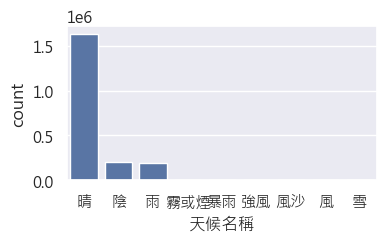

In [15]:
plt.figure(figsize = (4, 2))
sns.countplot(data_unique, x = "天候名稱")
plt.show()

Reasons of occurence

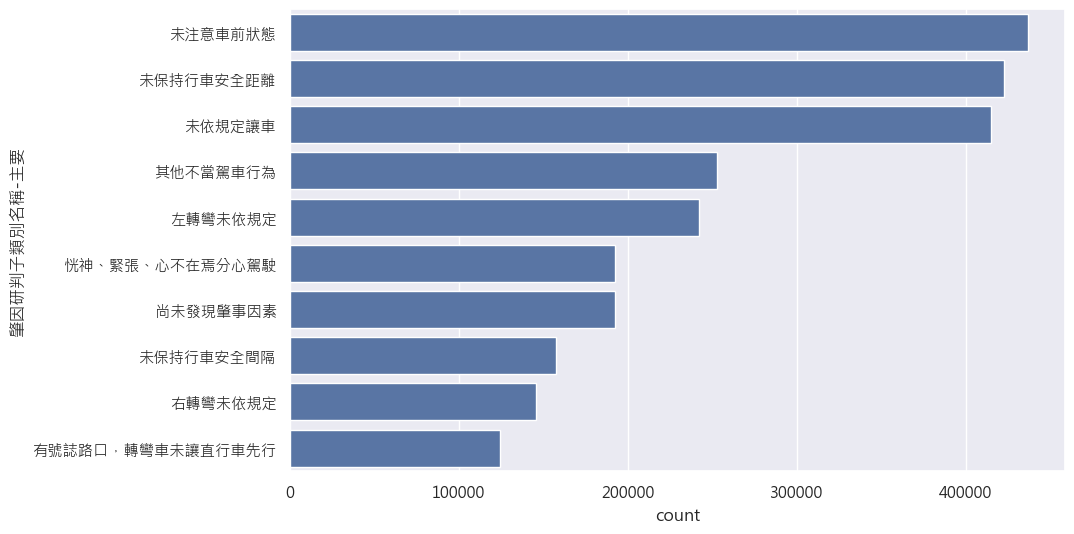

In [ ]:
# All
plt.figure(figsize = (10, 6))

top_causes = data["肇因研判子類別名稱-主要"].value_counts().nlargest(10).index

contextual_df = data[data["肇因研判子類別名稱-主要"].isin(top_causes)]

sns.countplot(data=contextual_df, y="肇因研判子類別名稱-主要", order=top_causes)

plt.show()

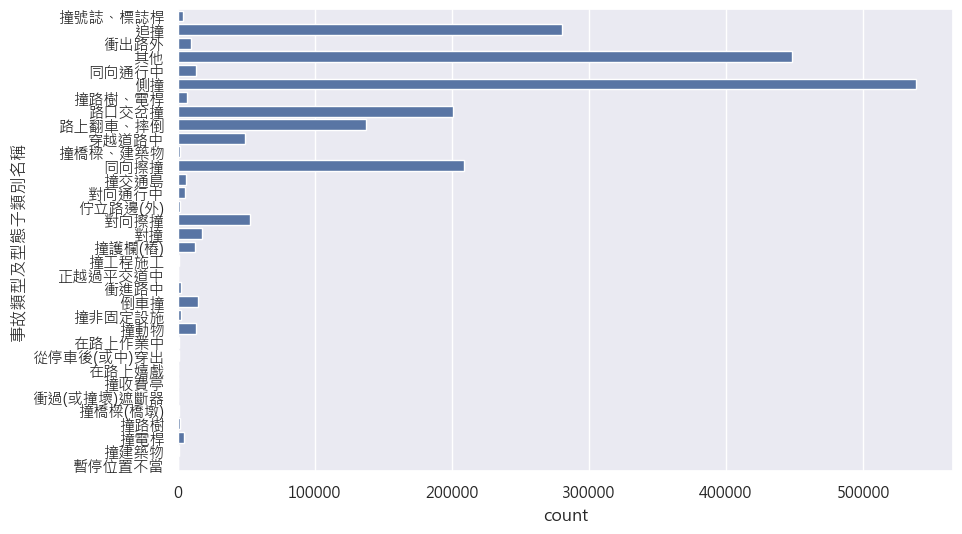

In [ ]:
# Unique
plt.figure(figsize = (10, 6))
sns.countplot(data_unique, y = "事故類型及型態子類別名稱")
plt.show()

#### Types of car (contain all records)

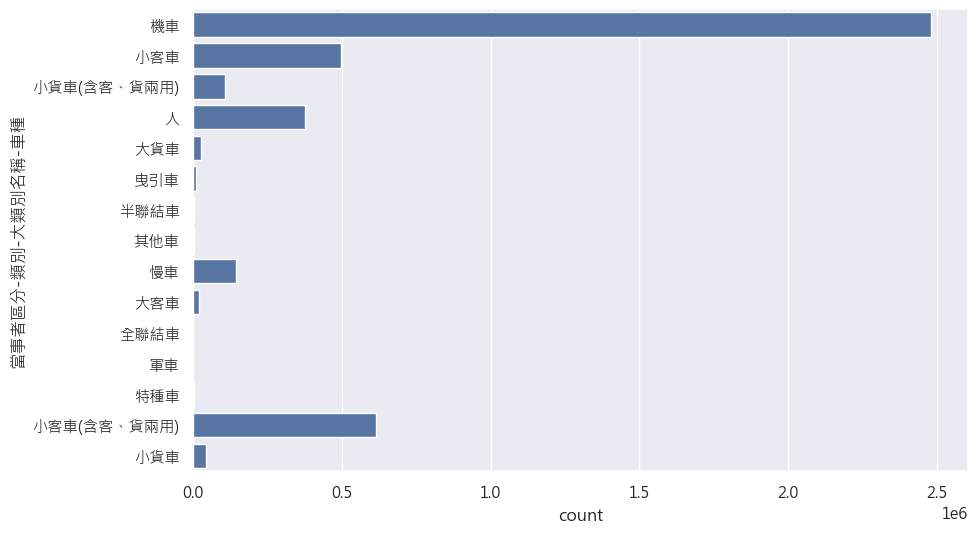

In [19]:
plt.figure(figsize = (10, 6))
sns.countplot(data, y = "當事者區分-類別-大類別名稱-車種")
plt.show()